# **Cuaderno 5.3 Pérdida de Entropía Cruzada Multiclase**

Este cuaderno investiga la pérdida de entropía cruzada multiclase. Se deriva de la aplicación de la fórmula de la sección 5.2 a una función de pérdida basada en la distribución Categórica.

Trabaje en las celdas siguientes, ejecutando cada una a su vez. En varios lugares verá las palabras "TO DO". Siga las instrucciones en estos lugares y haga predicciones sobre lo que va a suceder o escriba código para completar las funciones.

Contácteme en udlbookmail@gmail.com si encuentra algún error o tiene alguna sugerencia.

In [1]:
# Importa la librería math
import numpy as np
# Usado para repmat
import numpy.matlib
# Importa la librería de trazado
import matplotlib.pyplot as plt
# Importa la librería math
import math

In [2]:
# Define la función Rectified Linear Unit (ReLU)
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

# Define una red neuronal (shallow neural network)
def shallow_nn(x, beta_0, omega_0, beta_1, omaga_1):
    # Asegúrese de que los datos de entrada sean un array (1 x n_data)
    n_data = x.size
    x = np.reshape(x,(1,n_data))

    # Esto ejecuta la red para TODOS los inputs, x a la vez para que podamos dibujar el gráfico
    h1 = ReLU(np.matmul(beta_0,np.ones((1,n_data))) + np.matmul(omega_0,x))
    model_out = np.matmul(beta_1,np.ones((1,n_data))) + np.matmul(omega_1,h1)
    return model_out

In [3]:
# Obtener parámetros para el modelo -- podemos llamar a esta función para resetearlos fácilmente
def get_parameters():
  # Y crearemos una red que se ajuste aproximadamente
  beta_0 = np.zeros((3,1));  # anteriormente theta_x0
  omega_0 = np.zeros((3,1)); # anteriormente theta_x1
  beta_1 = np.zeros((3,1));  # NOTA -- ahora hay tres salidas (una para cada clase, por lo que tres sesgos de salida)
  omega_1 = np.zeros((3,3)); # NOTA -- ahora hay tres salidas (una para cada clase, por lo que nueve pesos de salida, conectando 3 unidades ocultas a 3 salidas)

  beta_0[0,0] = 0.3; beta_0[1,0] = -1.0; beta_0[2,0] = -0.5
  omega_0[0,0] = -1.0; omega_0[1,0] = 1.8; omega_0[2,0] = 0.65
  beta_1[0,0] = 2.0; beta_1[1,0] = -2; beta_1[2,0] = 0.0
  omega_1[0,0] = -24.0; omega_1[0,1] = -8.0; omega_1[0,2] = 50.0
  omega_1[1,0] = -2.0; omega_1[1,1] = 8.0; omega_1[1,2] = -30.0
  omega_1[2,0] = 16.0; omega_1[2,1] = -8.0; omega_1[2,2] =-8

  return beta_0, omega_0, beta_1, omega_1

In [4]:
# Función de utilidad para graficar datos
def plot_multiclass_classification(x_model, out_model, lambda_model, x_data = None, y_data = None, title= None):
  # Asegurarse de que los datos del modelo sean arrays 1D
  n_data = len(x_model)
  n_class = 3
  x_model = np.squeeze(x_model)
  out_model = np.reshape(out_model, (n_class,n_data))
  lambda_model = np.reshape(lambda_model, (n_class,n_data))

  fig, ax = plt.subplots(1,2)
  fig.set_size_inches(7.0, 3.5)
  fig.tight_layout(pad=3.0)
  ax[0].plot(x_model,out_model[0,:],'r-')
  ax[0].plot(x_model,out_model[1,:],'g-')
  ax[0].plot(x_model,out_model[2,:],'b-')
  ax[0].set_xlabel('Entrada, $x$'); ax[0].set_ylabel('Salidas del modelo')
  ax[0].set_xlim([0,1]);ax[0].set_ylim([-4,4])
  if title is not None:
    ax[0].set_title(title)
  ax[1].plot(x_model,lambda_model[0,:],'r-')
  ax[1].plot(x_model,lambda_model[1,:],'g-')
  ax[1].plot(x_model,lambda_model[2,:],'b-')
  ax[1].set_xlabel('Entrada, $x$'); ax[1].set_ylabel('$\\lambda$ o Pr(y=k|x)')
  ax[1].set_xlim([0,1]);ax[1].set_ylim([-0.1,1.05])
  if title is not None:
    ax[1].set_title(title)
  if x_data is not None:
    for i in range(len(x_data)):
      if y_data[i] ==0:
        ax[1].plot(x_data[i],-0.05, 'r.')
      if y_data[i] ==1:
        ax[1].plot(x_data[i],-0.05, 'g.')
      if y_data[i] ==2:
        ax[1].plot(x_data[i],-0.05, 'b.')
  plt.show()

# Multiclass classification

Para la multiclass classification, la red debe predecir la probabilidad de $K$ clases, usando $K$ salidas. Sin embargo, estas probabilidades deben ser no negativas y sumar uno, y las salidas de la red pueden tomar valores arbitrarios. Por lo tanto, pasamos las salidas a través de una función Softmax que mapea $K$ valores arbitrarios a $K$ valores no negativos que suman uno.

In [5]:
# Función Softmax que asigna un vector de valores arbitrarios a un vector de valores que son positivos y suman uno.
def softmax(model_out):
  # Esta operación debe hacerse por separado para cada columna de la entrada
  # Calcula las exponenciales de todos los elementos
  # TODO: calcular la función softmax (ecuación 5.22)
  # Reemplace este código esqueleto

  # Calcula el exponencial de las salidas del modelo
  exp_model_out = np.exp(model_out) ;
  # Calcula la suma de las exponenciales (denominador de la ecuación 5.22)
  sum_exp_model_out = np.sum(np.exp(model_out)) ;
  # Normaliza las exponenciales (np.matlib.repmat podría ser útil aquí)
  softmax_model_out = exp_model_out / sum_exp_model_out #exp_model_out.shape[0]

  return softmax_model_out

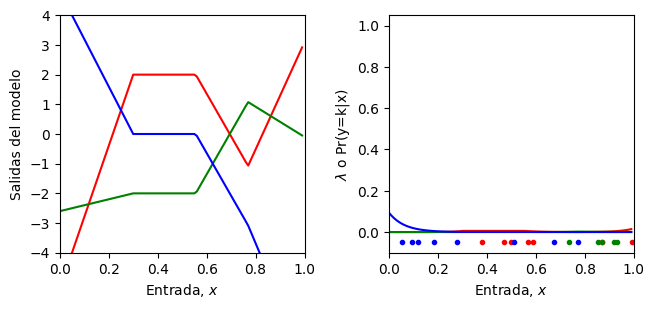

In [6]:

# Vamos a crear algunos datos de entrenamiento 1D
x_train = np.array([0.09291784,0.46809093,0.93089486,0.67612654,0.73441752,0.86847339,\
                   0.49873225,0.51083168,0.18343972,0.99380898,0.27840809,0.38028817,\
                   0.12055708,0.56715537,0.92005746,0.77072270,0.85278176,0.05315950,\
                   0.87168699,0.58858043])
y_train = np.array([2,0,1,2,1,0,\
                    0,2,2,0,2,0,\
                    2,0,1,2,1,2, \
                    1,0])

# Obtener parámetros para el modelo
beta_0, omega_0, beta_1, omega_1 = get_parameters()

# Definir un rango de valores de entrada
x_model = np.arange(0,1,0.01)
# Ejecutar el modelo para obtener valores a graficar y graficarlo.
model_out= shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
lambda_model = softmax(model_out)
plot_multiclass_classification(x_model, model_out, lambda_model, x_train, y_train)


A la izquierda está la salida del modelo y a la derecha está la salida del modelo después de aplicar la función Softmax, por lo que ahora se encuentra en el rango [0,1] y representa la probabilidad de que y=0 (rojo), 1 (verde) y 2 (azul). Los puntos en la parte inferior muestran los datos de entrenamiento con el mismo esquema de color. Así que queremos que la curva roja sea alta donde hay puntos rojos, la curva verde sea alta donde hay puntos verdes y la curva azul sea alta donde hay puntos azules. Calcularemos la verosimilitud y la negative log likelihood.

In [7]:
# Devuelve la probabilidad bajo la distribución Categórica para la entrada x
# Solo toma el valor de la fila k del parámetro lambda donde y = k,
def categorical_distribution(y, lambda_param):
    return np.array([lambda_param[row, i] for i, row in enumerate (y)])

In [8]:
# Verifiquemos que obtenemos la respuesta correcta antes de continuar
print("Respuesta correcta = %3.3f, Su respuesta = %3.3f"%(0.2,categorical_distribution(np.array([[0]]),np.array([[0.2],[0.5],[0.3]]))))
print("Respuesta correcta = %3.3f, Su respuesta = %3.3f"%(0.5,categorical_distribution(np.array([[1]]),np.array([[0.2],[0.5],[0.3]]))))
print("Respuesta correcta = %3.3f, Su respuesta = %3.3f"%(0.3,categorical_distribution(np.array([[2]]),np.array([[0.2],[0.5],[0.3]]))))


Respuesta correcta = 0.200, Su respuesta = 0.200
Respuesta correcta = 0.500, Su respuesta = 0.500
Respuesta correcta = 0.300, Su respuesta = 0.300


/tmp/ipykernel_7092/586207096.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Respuesta correcta = %3.3f, Su respuesta = %3.3f"%(0.2,categorical_distribution(np.array([[0]]),np.array([[0.2],[0.5],[0.3]]))))
/tmp/ipykernel_7092/586207096.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Respuesta correcta = %3.3f, Su respuesta = %3.3f"%(0.5,categorical_distribution(np.array([[1]]),np.array([[0.2],[0.5],[0.3]]))))
/tmp/ipykernel_7092/586207096.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before perfo

Ahora calculemos la verosimilitud usando esta función

In [9]:
# Devuelve la verosimilitud de todos los datos bajo el modelo
def compute_likelihood(y_train, lambda_param):
  # TODO -- calcular la verosimilitud de los datos -- el producto de las probabilidades categóricas para cada punto de datos
  # Línea superior de la ecuación 5.3 en las notas
  # Necesitará np.prod() y la función categorical_distribution que usó anteriormente
  # Reemplace la línea siguiente
  likelihood = np.prod(categorical_distribution(y_train, lambda_param))

  return likelihood

In [10]:
# Probemos esto
beta_0, omega_0, beta_1, omega_1 = get_parameters()
# Usamos nuestra neural network para predecir la media de la Gaussiana
model_out = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
lambda_train = softmax(model_out)

In [11]:
# Calcula la verosimilitud
likelihood = compute_likelihood(y_train, lambda_train)
# Verifiquemos que obtenemos la respuesta correcta antes de continuar
print("Respuesta correcta = %9.9f, Su respuesta = %9.9f"%(0.000000041,likelihood))

Respuesta correcta = 0.000000041, Su respuesta = 0.000000000


Puede ver que esto da una respuesta muy pequeña, incluso para este pequeño conjunto de datos 1D, y con el modelo ajustándose bastante bien. Esto se debe a que es el producto de varias probabilidades, que en sí mismas son bastante pequeñas.
Esto se descontrolará bastante rápido con conjuntos de datos reales: la verosimilitud se volverá tan pequeña que no podremos representarla con las matemáticas de precisión finita normales.

Por eso usamos negative log likelihood.

In [12]:
# Devuelve la negative log likelihood de los datos bajo el modelo
def compute_negative_log_likelihood(y_train, lambda_param):
  # TODO -- calcular la verosimilitud de los datos -- no use la función likelihood de arriba -- calcule la suma negativa de las probabilidades logarítmicas
  # Necesitará np.sum(), np.log()
  # Reemplace la línea siguiente
  nll = -np.sum(np.log(categorical_distribution(y_train, lambda_param)))

  return nll

In [13]:
# Probemos esto
beta_0, omega_0, beta_1, omega_1 = get_parameters()
# Usamos nuestra neural network para predecir la media de la Gaussiana
model_out = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
# Pasamos las salidas a través de la función Softmax
lambda_train = softmax(model_out)
# Calculamos la log likelihood
nll = compute_negative_log_likelihood(y_train, lambda_train)
# Verifiquemos que obtenemos la respuesta correcta antes de continuar
print("Respuesta correcta = %9.9f, Su respuesta = %9.9f"%(17.015457867,nll))

Respuesta correcta = 17.015457867, Su respuesta = 84.169759341


Ahora investiguemos cómo encontrar la solución de máxima verosimilitud / mínima log likelihood. Para simplificar, asumiremos que todos los parámetros están fijos excepto uno y observaremos cómo cambia la verosimilitud y la log likelihood a medida que manipulamos el último parámetro. Comenzaremos con el y_offset general, beta_1 (anteriormente phi_0)

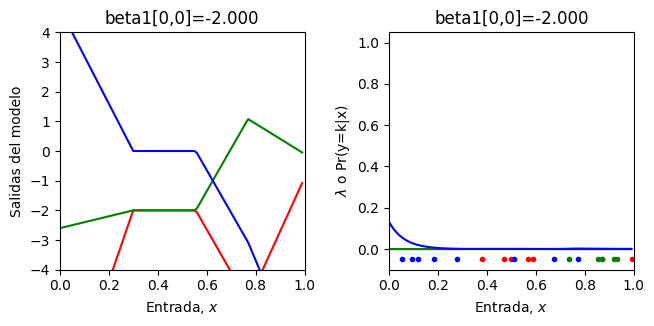

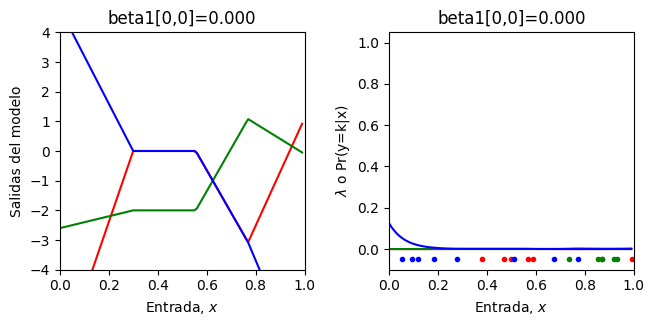

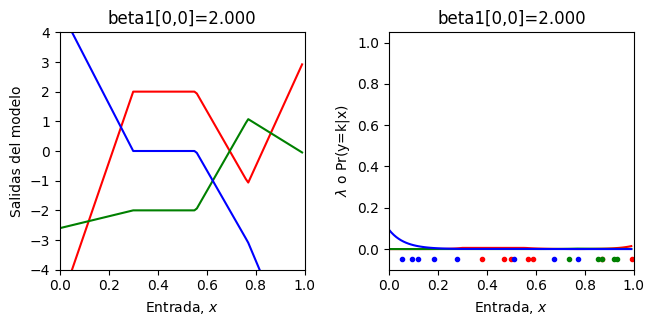

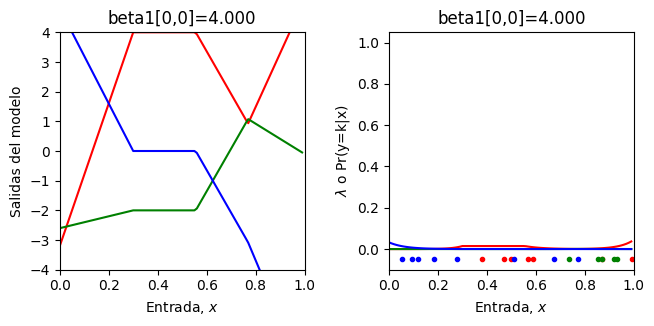

In [14]:
# Definir un rango de valores para el parámetro
beta_1_vals = np.arange(-2,6.0,0.1)
# Crear algunos arrays para almacenar las likelihoods, negative log likelihoods
likelihoods = np.zeros_like(beta_1_vals)
nlls = np.zeros_like(beta_1_vals)

# Inicializar los parámetros
beta_0, omega_0, beta_1, omega_1 = get_parameters()
for count in range(len(beta_1_vals)):
  # Establecer el valor para el parámetro
  beta_1[0,0] = beta_1_vals[count]
  # Ejecutar la red con nuevos parámetros
  model_out = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
  lambda_train = softmax(model_out)
  # Calcular y almacenar los tres valores
  likelihoods[count] = compute_likelihood(y_train,lambda_train)
  nlls[count] = compute_negative_log_likelihood(y_train, lambda_train)
  # Dibujar el modelo para cada 20ª configuración de parámetros
  if count % 20 == 0:
    # Ejecutar el modelo para obtener valores a graficar y graficarlo.
    model_out = shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
    lambda_model = softmax(model_out)
    plot_multiclass_classification(x_model, model_out, lambda_model, x_train, y_train, title="beta1[0,0]=%3.3f"%(beta_1[0,0]))

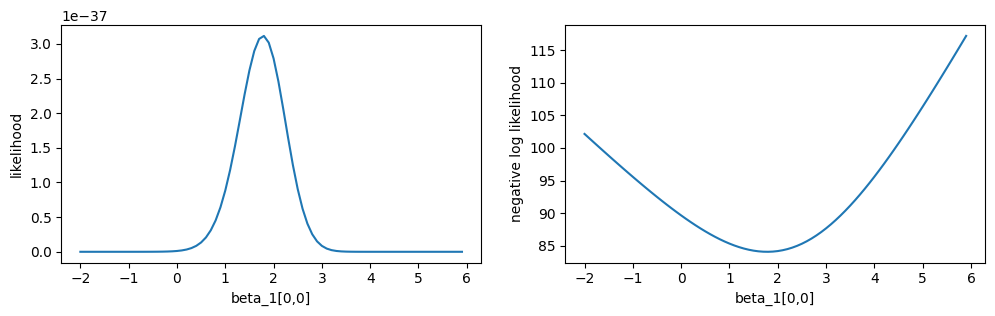

In [15]:
# Ahora tracemos la verosimilitud, negative log likelihood como una función del valor del offset beta1
fig, ax = plt.subplots(1,2)
fig.set_size_inches(10.5, 3.5)
fig.tight_layout(pad=3.0)
ax[0].plot(beta_1_vals, likelihoods); ax[0].set_xlabel('beta_1[0,0]'); ax[0].set_ylabel('likelihood')
ax[1].plot(beta_1_vals, nlls); ax[1].set_xlabel('beta_1[0,0]'); ax[1].set_ylabel('negative log likelihood')
plt.show()

Máxima verosimilitud = 0.000000, en beta_1=1.800
Mínima negative log likelihood = 84.059449, en beta_1=1.800


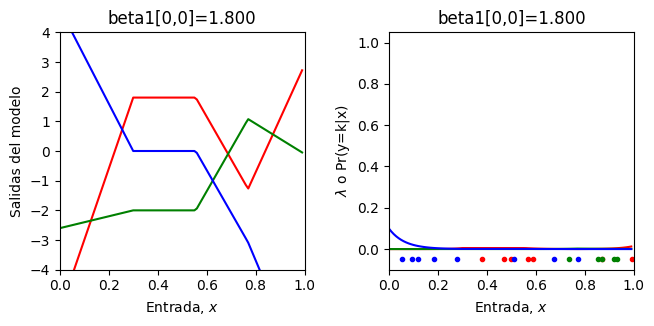

In [16]:
# Con suerte, puede ver que el máximo de la función de verosimilitud está en la misma posición que la solución de mínimo negative log likelihood
# Verifiquemos eso:
print("Máxima verosimilitud = %f, en beta_1=%3.3f"%( (likelihoods[np.argmax(likelihoods)],beta_1_vals[np.argmax(likelihoods)])))
print("Mínima negative log likelihood = %f, en beta_1=%3.3f"%( (nlls[np.argmin(nlls)],beta_1_vals[np.argmin(nlls)])))

# Graficar el mejor modelo
beta_1[0,0] = beta_1_vals[np.argmin(nlls)]
model_out = shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
lambda_model = softmax(model_out)
plot_multiclass_classification(x_model, model_out, lambda_model, x_train, y_train, title="beta1[0,0]=%3.3f"%(beta_1[0,0]))


Ambos dan la misma respuesta. Pero puede ver en la verosimilitud anterior que la verosimilitud es muy pequeña a menos que los parámetros sean casi correctos. Así que, en la práctica, trabajaríamos con la negative log likelihood.<br><br>

De nuevo, para ajustar el modelo neural completo, variaríamos todos los 16 parámetros de la red en $\boldsymbol\beta_{0},\boldsymbol\omega_{0},\boldsymbol\beta_{1},\boldsymbol\omega_{1}$ hasta encontrar la combinación que tenga la máxima verosimilitud / mínima negative log likelihood.